# Compare decoders logical error rates

This notebook will evaluate the accuracy of a list of decoders given a list of codes and noises.
It will use exactly the same sequence of syndrome such that better comparison could be done even with fewer data.

This notebook only provides basic plotting.

To execute this notebook with a custom code, noise and list of decoders, use
```sh
# srun --time=1-00:00:00 --mem=10G --cpus-per-task=2 \
python3 -m qec_lego_bench notebook-pl-p-compare-decoders ./dist/pl_p_compare_decoders_example.ipynb 'rsc(d=3;p=0.01)' --decoder 'mwpm' --decoder 'mwpf(c=0)' --decoder 'mwpf(c=50)' --target-precision 0.1 --local-maximum-jobs 8
```

In [1]:

codes: list[str] = ["css_rsc(d@3)", "css_rsc(d@3)", "css_rsc(d@5)", "css_rsc(d@5)"]
noises: list[str] = ["depolarize(p@0.05)", "depolarize(p@0.08)", "depolarize(p@0.05)", "depolarize(p@0.08)"]
decoders: list[str] = ["mwpf", "mwpm"]

max_cpu_hours: float = None
min_precision: float = 1
target_precision: float = 0.04  # about 4000 errors for the configuration with the smallest 
high_pL_threshold: float = 0.2  # we do care about high logical error rates since we want to know the threshold

# adaptive min shots submitter
min_shots: int = 1000
max_shots: int = 1000000
max_errors: int = 20  # the submitter terminates when the number of errors exceeds this value
max_adaptive_min_shots_cpu_hours: float = None

slurm_maximum_jobs: int = 50  # start with a smaller number of workers to avoid resource waste
slurm_cores_per_node: int = 10  # (slurm_maximum_jobs // slurm_cores_per_node) should not exceed 200
slurm_mem_per_job: int = 4  # 4GB per job
slurm_extra: dict = dict(
    walltime = "1-00:00:00",  # adaptively shutdown if no more jobs
    queue = "scavenge",  # use with caution: dask does not seem to handle scavenge workers well
    job_extra_directives = ["--requeue"],  # use with scavenge partition will help spawn scavenged jobs
)

import multiprocessing
local_maximum_jobs: int = multiprocessing.cpu_count()

json_filename: str = None
cpu: str = "unknown"
force_finished: bool = False  # only plot the figure and do not run experiments

In [2]:
# Parameters
codes = ["rsc(d@3;p@0.015)", "rsc(d@5;p@0.015)", "rsc(d@7;p@0.015)", "rsc(d@9;p@0.015)", "rsc(d@11;p@0.015)", "rsc(d@3;p@0.01)", "rsc(d@5;p@0.01)", "rsc(d@7;p@0.01)", "rsc(d@9;p@0.01)", "rsc(d@11;p@0.01)", "rsc(d@3;p@0.007)", "rsc(d@5;p@0.007)", "rsc(d@7;p@0.007)", "rsc(d@9;p@0.007)", "rsc(d@11;p@0.007)", "rsc(d@3;p@0.005)", "rsc(d@5;p@0.005)", "rsc(d@7;p@0.005)", "rsc(d@9;p@0.005)", "rsc(d@11;p@0.005)", "rsc(d@3;p@0.003)", "rsc(d@5;p@0.003)", "rsc(d@7;p@0.003)", "rsc(d@9;p@0.003)", "rsc(d@11;p@0.003)", "rsc(d@3;p@0.002)", "rsc(d@5;p@0.002)", "rsc(d@7;p@0.002)", "rsc(d@9;p@0.002)", "rsc(d@11;p@0.002)", "rsc(d@3;p@0.001)", "rsc(d@5;p@0.001)", "rsc(d@7;p@0.001)", "rsc(d@3;p@0.0005)", "rsc(d@5;p@0.0005)", "rsc(d@3;p@0.0002)", "rsc(d@3;p@0.0001)"]
noises = ["none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none", "none"]
decoders = ["fb(max_tree_size@0)", "fb", "mwpf(c@0)", "mwpf(c@200)"]
json_filename = "circuit-rsc-c200.json"
target_precision = 0.06
high_pL_threshold = 0.1
max_shots = 10000000
slurm_maximum_jobs = 500
local_maximum_jobs = 47


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
codes = [code.replace("@", "=").replace(";", ",") for code in codes]
noises = [noise.replace("@", "=").replace(";", ",") for noise in noises]
decoders = [decoder.replace("@", "=").replace(";", ",") for decoder in decoders]

from qec_lego_bench.notebooks.pL_p_compare_decoders import *
from qec_lego_bench.notebooks.compare_decoder import CompareDecoderMonteCarloFunction

codes, noises = sanity_check_parse_codes_and_noises(codes, noises)

if json_filename is None:
    json_filename = default_json_filename()
print("saving results to:", json_filename)

if max_cpu_hours is not None and max_adaptive_min_shots_cpu_hours is None:
    max_adaptive_min_shots_cpu_hours = max_cpu_hours


saving results to: circuit-rsc-c200.json


In [5]:
jobs = [MonteCarloJob(code=code, noise=noise) for code, noise in zip(codes, noises)]

monte_carlo_function = CompareDecoderMonteCarloFunction(
    decoders=decoders,
)

if not force_finished:
    print(monte_carlo_function(10, code=codes[0], noise=noises[0], verbose=True))

Writing Circuit file to /tmp/tmp504p3qw8/tmp.stim
Writing DEM file to /tmp/tmp504p3qw8/tmp.dem
Writing detectors to /tmp/tmp504p3qw8/tmp.det.b8 and observables to /tmp/tmp504p3qw8/tmp.obs.b8


  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:00<00:00,  9.49it/s]

 75%|███████▌  | 3/4 [00:00<00:00, 12.35it/s]

100%|██████████| 4/4 [00:00<00:00, 11.30it/s]

(10, MultiDecoderLogicalErrorRates(results={'fb(max_tree_size=0)': LogicalErrorResult(errors=1, discards=0, panic_cases=None, elapsed=0.0007939340236286322), 'fb': LogicalErrorResult(errors=1, discards=0, panic_cases=None, elapsed=0.0005325279845338729), 'mwpf(c=0)': LogicalErrorResult(errors=2, discards=0, panic_cases=None, elapsed=0.0016605549026280646), 'mwpf(c=200)': LogicalErrorResult(errors=2, discards=0, panic_cases=None, elapsed=0.007079896588240647)}))


In [6]:
adaptive_min_shots_submitter = AdaptiveMinShotsSubmitter(
    min_shots=min_shots,
    max_shots=max_shots,
    max_errors=max_errors,
    time_limit=max_adaptive_min_shots_cpu_hours * 3600 if max_adaptive_min_shots_cpu_hours is not None else None,
)

precision_submitter = PrecisionSubmitter(
    time_limit=max_cpu_hours * 3600 if max_cpu_hours is not None else None,
    min_precision=min_precision,
    target_precision=target_precision,
    high_pL_threshold=high_pL_threshold,
)

def submitter(executor: MonteCarloJobExecutor) -> list[tuple[MonteCarloJob, int]]:
    submit = adaptive_min_shots_submitter(executor)
    if len(submit) == 0 and executor.no_pending():  # previous submitter all finished
        submit += precision_submitter(executor)
    return submit

In [7]:
config = MonteCarloExecutorConfig()
config.max_submitted_job = max(config.max_submitted_job, 3 * slurm_maximum_jobs)
executor = MonteCarloJobExecutor(
    monte_carlo_function,
    jobs,
    config=config,
    filename=json_filename,
    result_type=MultiDecoderLogicalErrorRates,
)

client_connector = SlurmClientConnector(
    slurm_maximum_jobs=slurm_maximum_jobs,
    slurm_cores_per_node=slurm_cores_per_node,
    slurm_mem_per_job=slurm_mem_per_job,
    slurm_extra=slurm_extra,
    local_maximum_jobs=local_maximum_jobs,
)

,Status,JobKey,Job,Finished,Pending,Submitted,1500 jobs,Total,Duration,Errors,Discards,Panics,Error Rate
0,pending,92207b,"Job(code=rsc(d=11,p=0.002), noise=none)",126017612 (99%),736442 (0%),430500 (0%),1500 (100%),126754054,78766685.5s (1312778.1min),1849,0,0,1.47(9)e-05
1,finished,7fe341,"Job(code=rsc(d=11,p=0.003), noise=none)",15329464 (100%),0 (0%),0 (0%),0 (0%),15329464,37258457.2s (620974.3min),3662,0,0,0.00024(1)
2,finished,906280,"Job(code=rsc(d=11,p=0.005), noise=none)",612881 (100%),0 (0%),0 (0%),0 (0%),612881,5329336.7s (88822.3min),4163,0,0,0.0068(3)
3,finished,dda569,"Job(code=rsc(d=11,p=0.007), noise=none)",104509 (100%),0 (0%),0 (0%),0 (0%),104509,1309534.3s (21825.6min),4574,0,0,0.044(2)
4,finished,fac0c6,"Job(code=rsc(d=11,p=0.01), noise=none)",1026 (100%),0 (0%),0 (0%),0 (0%),1026,90336.6s (1505.6min),190,0,0,0.19(3)
5,finished,9745fe,"Job(code=rsc(d=11,p=0.015), noise=none)",412 (100%),0 (0%),0 (0%),0 (0%),412,301081.0s (5018.0min),174,0,0,0.42(6)
6,finished,79d778,"Job(code=rsc(d=3,p=0.0001), noise=none)",670358765 (100%),0 (0%),0 (0%),0 (0%),670358765,75139.6s (1252.3min),4305,0,0,6.4(3)e-06
7,finished,e4d311,"Job(code=rsc(d=3,p=0.0002), noise=none)",164965063 (100%),0 (0%),0 (0%),0 (0%),164965063,17325.6s (288.8min),4170,0,0,2.5(1)e-05
8,finished,333930,"Job(code=rsc(d=3,p=0.0005), noise=none)",26630400 (100%),0 (0%),0 (0%),0 (0%),26630400,2966.3s (49.4min),4241,0,0,0.000159(6)
9,finished,51f549,"Job(code=rsc(d=3,p=0.001), noise=none)",6657600 (100%),0 (0%),0 (0%),0 (0%),6657600,896.1s (14.9min),4207,0,0,0.00063(3)


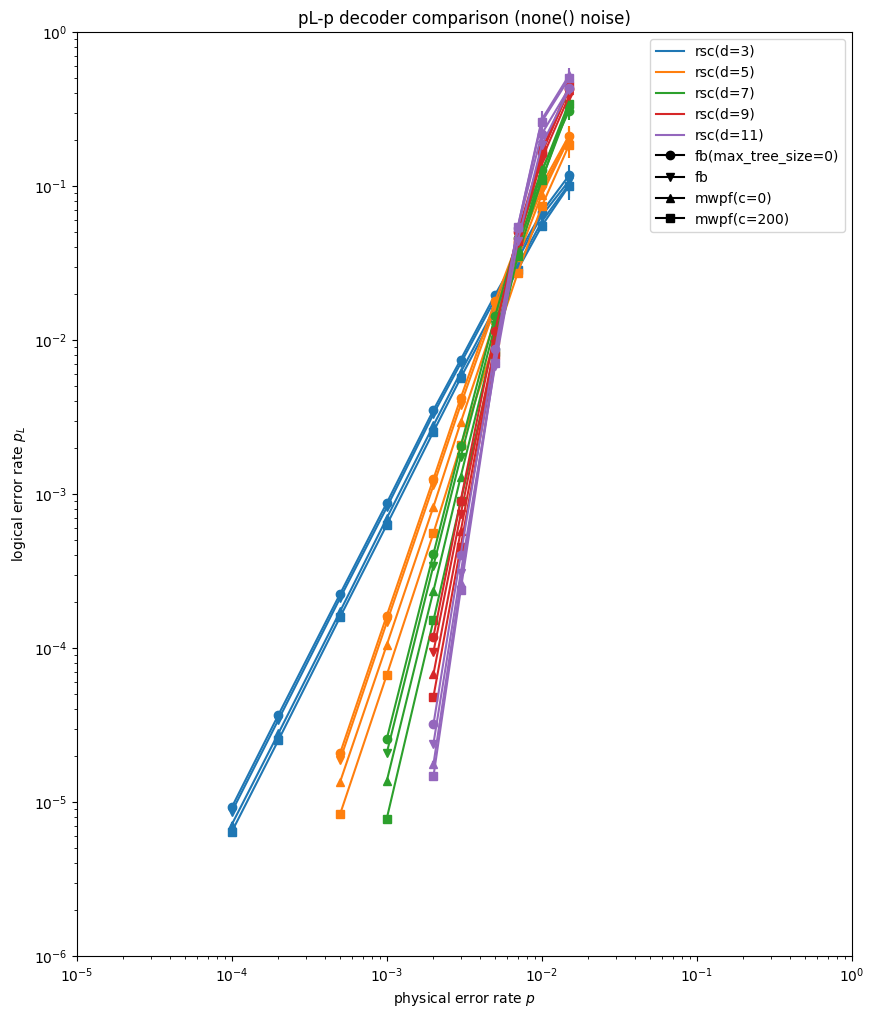

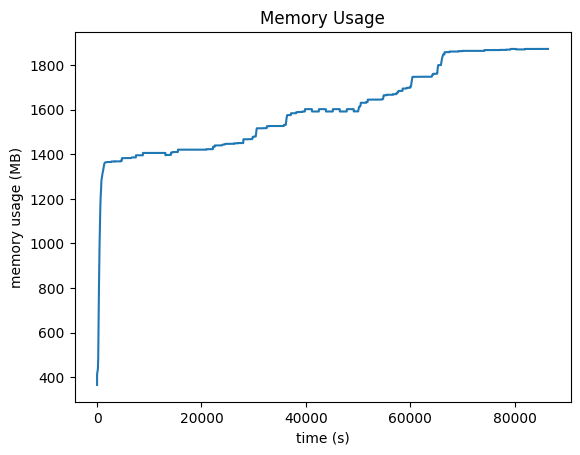

winding up a new client


#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -p scavenge
#SBATCH -n 1
#SBATCH --cpus-per-task=10
#SBATCH --mem=38G
#SBATCH -t 1-00:00:00
#SBATCH --out="/gpfs/gibbs/project/lin_zhong/yw729/PaperMWPFEvaluation/accuracy/circuit-rsc/slurm_job/%j.out"
#SBATCH --error="/gpfs/gibbs/project/lin_zhong/yw729/PaperMWPFEvaluation/accuracy/circuit-rsc/slurm_job/%j.err"
#SBATCH --requeue

/home/yw729/.conda/envs/qec/bin/python -m distributed.cli.dask_worker tcp://10.181.187.16:35007 --name dummy-name --nthreads 1 --memory-limit 3.73GiB --nworkers 10 --nanny --death-timeout 60

cluster dashboard link: http://10.181.187.16:8787/status


In [8]:
import time  # add some sleep to let them work properly in VScode Jupyter notebook

time.sleep(0.2)
progress_plotter = JobProgressPlotter()
time.sleep(0.2)
compare_decoder_plotter = PlPCompareDecodersPlotter(
    decoders = decoders, codes=codes, noises=noises
)
time.sleep(0.2)
memory_plotter = MemoryUsagePlotter()


def callback(executor: MonteCarloJobExecutor):
    progress_plotter(executor)
    time.sleep(0.1)
    compare_decoder_plotter(executor)
    time.sleep(0.1)
    memory_plotter(executor)
    time.sleep(0.1)


executor.execute(
    client_connector=client_connector,
    submitter=submitter,
    loop_callback=callback,
    shutdown_cluster=True,
    force_finished=force_finished,
)